In [ ]:
!pip install -r requirements.txt

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('OnlineRetail.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom
1,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
2,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
3,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom
4,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom
...,...,...,...,...,...,...,...,...
203417,558637,22032,BOTANICAL LILY GREETING CARD,12,2011-06-30 20:08:00,0.42,17891.0,United Kingdom
203418,558637,22028,PENNY FARTHING BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891.0,United Kingdom
203419,558637,22033,BOTANICAL ROSE GREETING CARD,12,2011-06-30 20:08:00,0.42,17891.0,United Kingdom
203420,558637,22029,SPACEBOY BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891.0,United Kingdom


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203422 entries, 0 to 203421
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    203422 non-null  object 
 1   StockCode    203422 non-null  object 
 2   Description  202623 non-null  object 
 3   Quantity     203422 non-null  int64  
 4   InvoiceDate  203422 non-null  object 
 5   UnitPrice    203422 non-null  float64
 6   CustomerID   150039 non-null  float64
 7   Country      203422 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 12.4+ MB


- `Description` & `CustomerID` have missing values 
- Conver data types of `InvoiceDate` & `CustomerID`

In [39]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,203422.000000,203422.000000,150039.000000
mean,9.585684,4.877820,15240.234832
std,240.921315,113.686676,1717.658493
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13791.000000
50%,3.000000,2.100000,15061.000000
75%,10.000000,4.130000,16771.000000
max,74215.000000,38970.000000,18287.000000


In [40]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.strip()
df["StockCode"] = df["StockCode"].astype(str).str.strip()
df["Description"] = df["Description"].astype(str).str.strip()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Country"] = df["Country"].astype(str).str.strip()

- Thường là các đơn hàng có InvoiceNo là C = các đơn hàng hủy hoặc các đơn hàng không có CustomerID

In [41]:
df['InvoiceDate'].agg(['min', 'max'])

min   2011-01-04 10:00:00
max   2011-06-30 20:08:00
Name: InvoiceDate, dtype: datetime64[ns]

In [42]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype('Int64')

In [43]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313,United Kingdom
1,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313,United Kingdom
2,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313,United Kingdom
3,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313,United Kingdom
4,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313,United Kingdom
...,...,...,...,...,...,...,...,...
203417,558637,22032,BOTANICAL LILY GREETING CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom
203418,558637,22028,PENNY FARTHING BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom
203419,558637,22033,BOTANICAL ROSE GREETING CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom
203420,558637,22029,SPACEBOY BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom


In [44]:
df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203422 entries, 0 to 203421
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    203422 non-null  object        
 1   StockCode    203422 non-null  object        
 2   Description  203422 non-null  object        
 3   Quantity     203422 non-null  int64         
 4   InvoiceDate  203422 non-null  datetime64[ns]
 5   UnitPrice    203422 non-null  float64       
 6   CustomerID   150039 non-null  Int64         
 7   Country      203422 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 12.6+ MB


In [45]:
# Cột nghiệp vụ chung cho tất cả các phân tích
df["TotalSpend"] = df["Quantity"] * df["UnitPrice"]
df["IsCancelled"] = df["InvoiceNo"].str.startswith("C") | (df["Quantity"] <= 0)

In [46]:
df_base = df.copy()
df_base 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,IsCancelled
0,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313,United Kingdom,19.50,False
1,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313,United Kingdom,10.50,False
2,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313,United Kingdom,10.50,False
3,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313,United Kingdom,10.50,False
4,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313,United Kingdom,12.50,False
...,...,...,...,...,...,...,...,...,...,...
203417,558637,22032,BOTANICAL LILY GREETING CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04,False
203418,558637,22028,PENNY FARTHING BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04,False
203419,558637,22033,BOTANICAL ROSE GREETING CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04,False
203420,558637,22029,SPACEBOY BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04,False


In [47]:
df_base[df_base['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,IsCancelled


**Extract ra bản dữ liệu có chứa cancellations phục vụ cho bài toán liên quan tới đơn hủy**

In [48]:
df_base

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,IsCancelled
0,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313,United Kingdom,19.50,False
1,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313,United Kingdom,10.50,False
2,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313,United Kingdom,10.50,False
3,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313,United Kingdom,10.50,False
4,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313,United Kingdom,12.50,False
...,...,...,...,...,...,...,...,...,...,...
203417,558637,22032,BOTANICAL LILY GREETING CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04,False
203418,558637,22028,PENNY FARTHING BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04,False
203419,558637,22033,BOTANICAL ROSE GREETING CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04,False
203420,558637,22029,SPACEBOY BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04,False


**Cleaning for EDA -> Cohort -> RFM**

In [49]:
df_clean = df_base.dropna(subset=['CustomerID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean = df_clean.drop(columns=["IsCancelled"])
df_clean #extract clean version 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313,United Kingdom,19.50
1,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313,United Kingdom,10.50
2,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313,United Kingdom,10.50
3,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313,United Kingdom,10.50
4,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313,United Kingdom,12.50
...,...,...,...,...,...,...,...,...,...
203417,558637,22032,BOTANICAL LILY GREETING CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04
203418,558637,22028,PENNY FARTHING BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04
203419,558637,22033,BOTANICAL ROSE GREETING CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04
203420,558637,22029,SPACEBOY BIRTHDAY CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,5.04


In [50]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146478 entries, 0 to 203421
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    146478 non-null  object        
 1   StockCode    146478 non-null  object        
 2   Description  146478 non-null  object        
 3   Quantity     146478 non-null  int64         
 4   InvoiceDate  146478 non-null  datetime64[ns]
 5   UnitPrice    146478 non-null  float64       
 6   CustomerID   146478 non-null  object        
 7   Country      146478 non-null  object        
 8   TotalSpend   146478 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 11.2+ MB


**EDA**

In [51]:
# Total Revenue
total_revenue = df_clean['TotalSpend'].sum()
print(f'Total Revenue: ${total_revenue:.2f}')

Total Revenue: $3421091.76


In [52]:
# Total Orders
total_orders = df_clean['InvoiceNo'].nunique()
print(f"Tổng số đơn hàng: {total_orders:,}")

Tổng số đơn hàng: 7,402


In [53]:
# Total Customers
total_customers = df_clean['CustomerID'].nunique()
print(f"Tổng số khách hàng duy nhất: {total_customers:,}")

Tổng số khách hàng duy nhất: 2,724


In [54]:
# Total Products
total_products = df_clean['StockCode'].nunique()
print(f"Số loại sản phẩm khác nhau: {total_products:,}")

Số loại sản phẩm khác nhau: 3,119


In [55]:
# Average Order Value (AOV)
avg_order_value = total_revenue / total_orders
print(f"Giá trị trung bình mỗi đơn (AOV): {avg_order_value:,.2f}")


Giá trị trung bình mỗi đơn (AOV): 462.18


In [56]:
# Total transactions
total_trans = len(df_clean)
print(f"Tổng số giao dịch: {total_trans:,}")

Tổng số giao dịch: 146,478


In [57]:
# Customers List
customers = df_clean['CustomerID'].unique()
customers

array(['13313', '18097', '16656', ..., '13745', '16498', '17891'],
      shape=(2724,), dtype=object)

In [58]:
# Numbers of transactions per customers
trans_per_cus = df_clean.groupby('CustomerID')['InvoiceNo'].count().sort_values(ascending=False).reset_index()
trans_per_cus.columns =['CustomerID', 'Num_Transactions']
trans_per_cus

,CustomerID,Num_Transactions
0,17841,2427
1,14911,1660
2,14606,1359
3,15311,1146
4,14646,967
...,...,...
2719,15885,1
2720,17956,1
2721,15510,1
2722,13185,1


In [59]:
# Revenue per month
rev_per_month = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalSpend'].sum().reset_index()
rev_per_month.columns = ['Month', 'Revenue']
rev_per_month

,Month,Revenue
0,2011-01,569445.040
1,2011-02,447137.350
2,2011-03,595500.760
3,2011-04,469200.361
4,2011-05,678594.560
5,2011-06,661213.690


**Cohort Analysis**

In [ ]:
# Input data into MySQL
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy.types import DateTime
from sqlalchemy import text

load_dotenv()

True

In [ ]:
connection_url = URL.create(
    drivername="mysql+pymysql",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME")
)

engine = create_engine(connection_url)

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean.to_sql(
    name="retail",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000,
    dtype={"InvoiceDate": DateTime()}
)

validation_query = """
SELECT 
    COUNT(*) AS total_records,
    MIN(InvoiceDate) AS first_transaction_date,
    MAX(InvoiceDate) AS last_transaction_date
FROM retail;
"""

df_validation = pd.read_sql(validation_query, con=engine)
display(df_validation)

,total_records,first_transaction_date,last_transaction_date
0,146478,2011-01-04 10:00:00,2011-06-30 20:08:00


In [69]:
cohort_query = text("""
WITH cohort_base AS (
    SELECT 
        CustomerID,
        DATE_FORMAT(InvoiceDate, '%Y-%m-01') AS InvoiceMonth,
        DATE_FORMAT(MIN(InvoiceDate) OVER(PARTITION BY CustomerID), '%Y-%m-01') AS CohortMonth
    FROM retail
    WHERE CustomerID IS NOT NULL 
      AND Quantity > 0
),
cohort_counts AS (
    SELECT 
        CohortMonth,
        PERIOD_DIFF(
            DATE_FORMAT(InvoiceMonth, '%Y%m'), 
            DATE_FORMAT(CohortMonth, '%Y%m')
        ) AS CohortIndex,
        COUNT(DISTINCT CustomerID) AS ActiveCustomers
    FROM cohort_base
    GROUP BY CohortMonth, CohortIndex
)
SELECT 
    CohortMonth,
    CohortIndex,
    ActiveCustomers,
    -- Lấy số khách tại CohortIndex = 0 của chính CohortMonth đó làm mẫu số
    FIRST_VALUE(ActiveCustomers) OVER(
        PARTITION BY CohortMonth 
        ORDER BY CohortIndex ASC
    ) AS InitialCustomers,
    -- Tính tỷ lệ RetentionRate (0.0 đến 1.0)
    ROUND(
        ActiveCustomers * 1.0 / FIRST_VALUE(ActiveCustomers) OVER(
            PARTITION BY CohortMonth 
            ORDER BY CohortIndex ASC
        ), 
        4
    ) AS RetentionRate
FROM cohort_counts
ORDER BY CohortMonth, CohortIndex;
""")

with engine.connect() as conn:
    df_cohort = pd.read_sql(cohort_query, con=conn)

# Xuất thẳng file CSV cho Power BI
df_cohort.to_csv("Cohort_Retention_Data.csv", index=False)

display(df_cohort.head(15))

,CohortMonth,CohortIndex,ActiveCustomers,InitialCustomers,RetentionRate
0,2011-01-01,0,741,741,1.0000
1,2011-01-01,1,262,741,0.3536
2,2011-01-01,2,319,741,0.4305
3,2011-01-01,3,284,741,0.3833
4,2011-01-01,4,339,741,0.4575
5,2011-01-01,5,311,741,0.4197
6,2011-02-01,0,496,496,1.0000
7,2011-02-01,1,116,496,0.2339
8,2011-02-01,2,123,496,0.2480
9,2011-02-01,3,169,496,0.3407


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

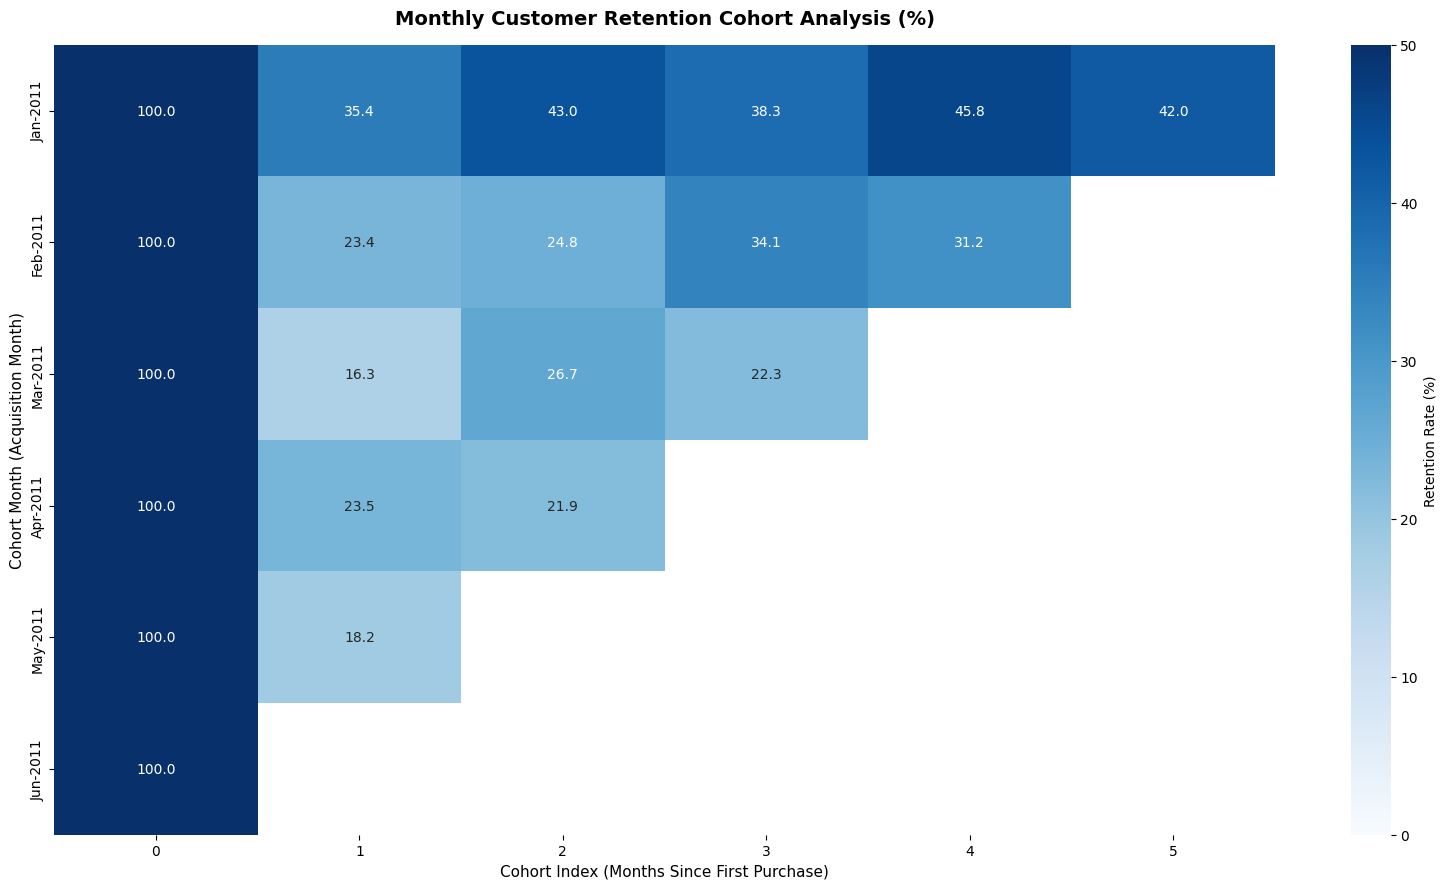

In [70]:
df_plot = df_cohort.copy()

# 1. Định dạng ngày và sắp xếp thứ tự Cohort
df_plot["CohortDate"] = pd.to_datetime(df_plot["CohortMonth"])
df_plot = df_plot.sort_values(by=["CohortDate", "CohortIndex"])

# 2. Hiển thị nhãn tháng-năm chuẩn (VD: Dec-2010, Jan-2011)
ordered_labels = df_plot["CohortDate"].dt.strftime("%b-%Y").unique()
df_plot["CohortDisplay"] = pd.Categorical(
    df_plot["CohortDate"].dt.strftime("%b-%Y"),
    categories=ordered_labels,
    ordered=True,
)

# 3. Pivot trực tiếp từ cột RetentionRate (nhân 100 để hiển thị %)
df_plot["RetentionPct"] = df_plot["RetentionRate"] * 100
retention_matrix = df_plot.pivot(
    index="CohortDisplay", 
    columns="CohortIndex", 
    values="RetentionPct"
)

# 4. Vẽ Heatmap
plt.figure(figsize=(16, 9))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=50,
    cbar_kws={"label": "Retention Rate (%)"},
)

plt.title(
    "Monthly Customer Retention Cohort Analysis (%)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Cohort Index (Months Since First Purchase)", fontsize=11)
plt.ylabel("Cohort Month (Acquisition Month)", fontsize=11)
plt.tight_layout()
plt.show()

### Key Insights: Customer Retention Analysis

* **Tỷ lệ rời bỏ cao ngay tháng đầu (Month 1 Drop-off):** Tỷ lệ giữ chân giảm mạnh từ 100% xuống còn 16.3% – 35.4% ở tất cả các nhóm (tương đương 65% – 84% khách hàng chỉ mua 1 lần rồi rời đi), phản ánh đặc thù hành vi mua sắm trong ngành bán lẻ.

* **Chu kỳ hồi phục mua lại ở tháng 2–4 (Repurchase Resurgence):** Khách hàng có xu hướng quay lại theo chu kỳ 60–120 ngày thay vì mua đều đặn hàng tháng. Nhóm `01-Jan` tăng trở lại từ 35.4% (M1) lên 43.0% (M2) và đạt đỉnh 45.7% (M4); nhóm `01-Feb` cũng tăng từ 23.4% (M1) lên 34.1% (M3).

* **Chất lượng vượt trội của tệp khách hàng Tháng 1:** Nhóm `01-Jan` có giá trị vòng đời (LTV) cao nhất, liên tục duy trì tỷ lệ giữ chân trên 35% và chạm mốc 42.0% – 45.7% ở các tháng sau, vượt trội hoàn toàn so với các nhóm từ tháng 2 đến tháng 5 (chỉ đạt 16% – 24% ở M1).

* **Đề xuất hành động CRM:** Cần thiết lập ưu đãi kích cầu đơn hàng thứ hai (Second-purchase incentive) trong vòng 20–30 ngày đầu để giảm tỷ lệ rớt M1, đồng thời triển khai luồng email/SMS nuôi dưỡng tự động vào khoảng ngày thứ 40–50 để đón đầu chu kỳ mua sắm lặp lại tự nhiên.

**RFM Analysis**

In [65]:
rfm_query = text("""
WITH snapshot AS (
    SELECT DATE_ADD(MAX(InvoiceDate), INTERVAL 1 DAY) AS snapshot_date
    FROM retail
)
SELECT 
    t.CustomerID,
    DATEDIFF((SELECT snapshot_date FROM snapshot), MAX(t.InvoiceDate)) AS Recency,
    COUNT(DISTINCT t.InvoiceNo) AS Frequency,
    ROUND(SUM(t.Quantity * t.UnitPrice), 2) AS Monetary
FROM retail t
WHERE t.CustomerID IS NOT NULL
GROUP BY t.CustomerID
HAVING Monetary > 0;
""")

with engine.connect() as conn:
    rfm = pd.read_sql(rfm_query, con=conn)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,164,1,77183.60
1,12347,22,3,1494.16
2,12348,87,2,594.44
3,12350,149,1,334.40
4,12352,101,5,1561.81


In [66]:
# 1. Tính điểm R, F, M (thang 1 - 5)
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# 2. Tạo chuỗi RFM Score (R-F-M)
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# 3. Định nghĩa bảng phân nhóm chuẩn CRM dựa trên cặp (R, F)
segment_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At-Risk',
    r'[1-2]5': 'Cannot Lose Them',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

# 4. Gán nhãn phân khúc
rfm['Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str)
rfm['Segment'] = rfm['Segment'].replace(segment_map, regex=True)

rfm

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,12346,164,1,77183.60,1,1,5,115,Hibernating
1,12347,22,3,1494.16,4,4,5,445,Loyal Customers
2,12348,87,2,594.44,2,3,3,233,At-Risk
3,12350,149,1,334.40,1,1,2,112,Hibernating
4,12352,101,5,1561.81,2,5,5,255,Cannot Lose Them
...,...,...,...,...,...,...,...,...,...
2719,18273,96,1,51.00,2,3,1,231,At-Risk
2720,18280,116,1,180.60,1,3,1,131,At-Risk
2721,18281,19,1,80.82,4,3,1,431,Potential Loyalists
2722,18283,8,7,842.58,5,5,4,554,Champions


In [67]:
segment_analysis = rfm.groupby('Segment').agg(
    Recency_mean=('Recency', 'mean'),
    Frequency_mean=('Frequency', 'mean'),
    Monetary_mean=('Monetary', 'mean'),
    Customer_Count=('CustomerID', 'count'),
    Total_Revenue=('Monetary', 'sum')
).round(1)

# Tính tỷ trọng % khách hàng và % doanh thu
segment_analysis['Customer_Share_%'] = (
    segment_analysis['Customer_Count'] / rfm.shape[0] * 100
).round(1)

segment_analysis['Revenue_Share_%'] = (
    segment_analysis['Total_Revenue'] / rfm['Monetary'].sum() * 100
).round(1)

# Sắp xếp theo tổng doanh thu mang lại
segment_analysis = segment_analysis.sort_values(by='Total_Revenue', ascending=False)
display(segment_analysis)

,Recency_mean,Frequency_mean,Monetary_mean,Customer_Count,Total_Revenue,Customer_Share_%,Revenue_Share_%
Segment,,,,,,,
Champions,8.1,7.5,3970.4,365,1449202.3,13.4,42.4
Loyal Customers,34.2,4.0,1677.1,557,934126.1,20.4,27.3
Hibernating,117.2,1.0,468.1,690,322966.0,25.3,9.4
At-Risk,102.8,1.8,773.8,371,287077.5,13.6,8.4
Potential Loyalists,17.4,1.4,526.0,300,157812.3,11.0,4.6
Need Attention,48.3,1.7,784.0,142,111322.4,5.2,3.3
About to Sleep,49.2,1.0,382.6,160,61208.2,5.9,1.8
Cannot Lose Them,90.2,4.5,1787.1,26,46465.0,1.0,1.4
Promising,26.4,1.0,496.4,66,32760.5,2.4,1.0


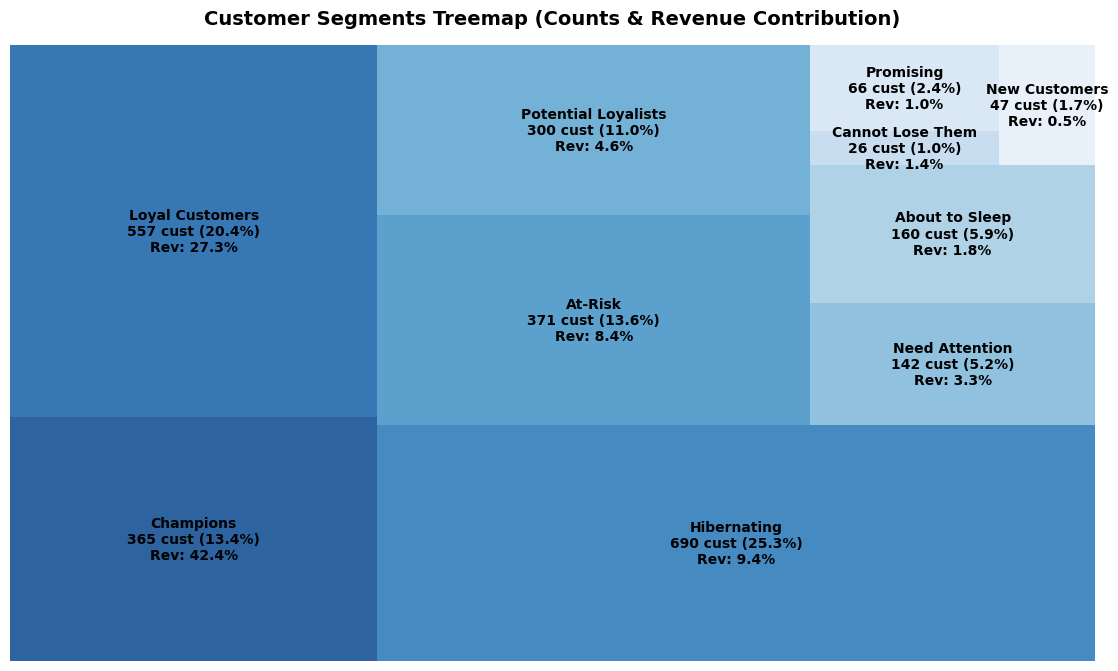

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

# 1. Vẽ Treemap trực quan tỷ trọng các nhóm
plt.figure(figsize=(14, 8))
labels = [
    f"{seg}\n{count:,} cust ({share}%)\nRev: {rev_share}%"
    for seg, count, share, rev_share in zip(
        segment_analysis.index,
        segment_analysis['Customer_Count'],
        segment_analysis['Customer_Share_%'],
        segment_analysis['Revenue_Share_%']
    )
]

squarify.plot(
    sizes=segment_analysis['Customer_Count'],
    label=labels,
    color=sns.color_palette("Blues_r", len(segment_analysis)),
    alpha=0.85,
    text_kwargs={'fontsize': 10, 'weight': 'bold'}
)
plt.title('Customer Segments Treemap (Counts & Revenue Contribution)', fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.show()